# NYC Yellow Taxi — DuckDB + MotherDuck

Queries `sample_data.nyc.taxi` on MotherDuck through a local DuckDB engine.
Requires `motherduck_token` in `../.env`.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))
load_dotenv()  # fallback if launched from repo root

token = os.environ['motherduck_token']
con = duckdb.connect(f'md:?motherduck_token={token}')
print('duckdb', duckdb.__version__)
print('local check:', con.sql('SELECT 42 AS answer').fetchone())

duckdb 1.5.2
local check: (42,)


## 1. Connection sanity check + schema

In [2]:
row_count = con.sql('SELECT COUNT(*) FROM sample_data.nyc.taxi').fetchone()[0]
print(f'sample_data.nyc.taxi rows: {row_count:,}')
con.sql('DESCRIBE sample_data.nyc.taxi').df()

sample_data.nyc.taxi rows: 3,252,717


,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,DOUBLE,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,DOUBLE,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,BIGINT,YES,None,None,None
8,DOLocationID,BIGINT,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [3]:
con.sql('FROM sample_data.nyc.taxi LIMIT 5').df()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2022-11-04 23:13:01,2022-11-04 23:25:38,4.0,1.78,1.0,N,230,239,1,10.0,0.5,0.5,2.76,0.0,0.3,16.56,2.5,0.0
1,2,2022-11-04 23:32:02,2022-11-04 23:41:31,1.0,1.09,1.0,N,142,141,2,7.5,0.5,0.5,0.00,0.0,0.3,11.30,2.5,0.0
2,1,2022-11-04 23:17:40,2022-11-04 23:25:40,2.0,0.80,1.0,N,230,68,1,6.5,3.0,0.5,2.05,0.0,0.3,12.35,2.5,0.0
3,2,2022-11-04 23:19:24,2022-11-04 23:32:21,1.0,1.62,1.0,N,163,90,1,10.0,0.5,0.5,2.76,0.0,0.3,16.56,2.5,0.0
4,2,2022-11-04 23:40:42,2022-11-04 23:52:26,1.0,2.08,1.0,N,186,143,1,10.0,0.5,0.5,2.50,0.0,0.3,16.30,2.5,0.0


## 2. Trip stats summary

In [4]:
con.sql("""
    SELECT
        COUNT(*)                       AS trips,
        ROUND(AVG(fare_amount), 2)     AS avg_fare,
        ROUND(MEDIAN(fare_amount), 2)  AS median_fare,
        ROUND(AVG(trip_distance), 2)   AS avg_distance_mi,
        ROUND(AVG(passenger_count), 2) AS avg_passengers,
        ROUND(AVG(total_amount), 2)    AS avg_total
    FROM sample_data.nyc.taxi
    WHERE fare_amount > 0 AND trip_distance > 0
""").df()

,trips,avg_fare,median_fare,avg_distance_mi,avg_passengers,avg_total
0,3171186,15.16,10.5,6.45,1.39,22.17


In [5]:
con.sql("""
    SELECT payment_type, COUNT(*) AS trips,
           ROUND(AVG(total_amount), 2) AS avg_total
    FROM sample_data.nyc.taxi
    GROUP BY payment_type
    ORDER BY trips DESC
""").df()

,payment_type,trips,avg_total
0,1,2483550,22.99
1,2,598081,18.26
2,0,121958,29.30
3,4,31334,1.63
4,3,17793,7.58
5,5,1,0.00


## 3. Daily trip volume

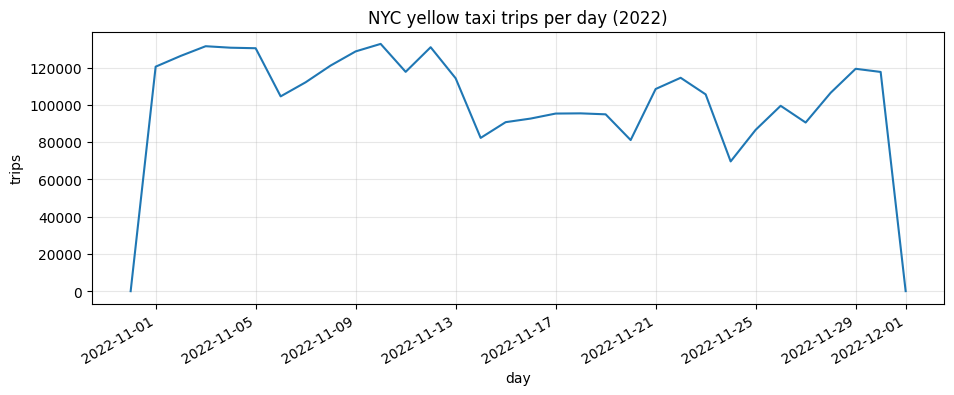

,day,trips
0,2022-10-31,34
1,2022-11-01,120506
2,2022-11-02,126271
3,2022-11-03,131484
4,2022-11-04,130682


In [6]:
daily = con.sql("""
    SELECT date_trunc('day', tpep_pickup_datetime) AS day,
           COUNT(*) AS trips
    FROM sample_data.nyc.taxi
    WHERE tpep_pickup_datetime >= '2022-01-01'
      AND tpep_pickup_datetime <  '2023-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily['day'], daily['trips'])
ax.set_title('NYC yellow taxi trips per day (2022)')
ax.set_xlabel('day')
ax.set_ylabel('trips')
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()
daily.head()

## 4. Top pickup locations

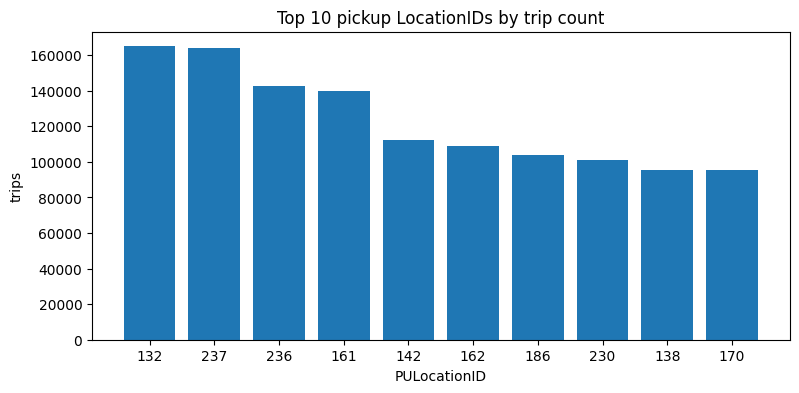

,PULocationID,trips,avg_fare
0,132,164957,45.72
1,237,163888,10.07
2,236,142776,10.69
3,161,140025,12.45
4,142,112137,11.31
5,162,109137,12.23
6,186,104008,12.98
7,230,101217,14.64
8,138,95320,31.55
9,170,95213,12.42


In [7]:
top = con.sql("""
    SELECT PULocationID,
           COUNT(*) AS trips,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM sample_data.nyc.taxi
    GROUP BY PULocationID
    ORDER BY trips DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(top['PULocationID'].astype(str), top['trips'])
ax.set_title('Top 10 pickup LocationIDs by trip count')
ax.set_xlabel('PULocationID')
ax.set_ylabel('trips')
plt.show()
top

## 5. Pickup location choropleth

Joins trip counts per `PULocationID` to the NYC TLC taxi-zone polygons
(`notebooks/data/taxi_zones/taxi_zones/taxi_zones.shp`) and renders a choropleth.

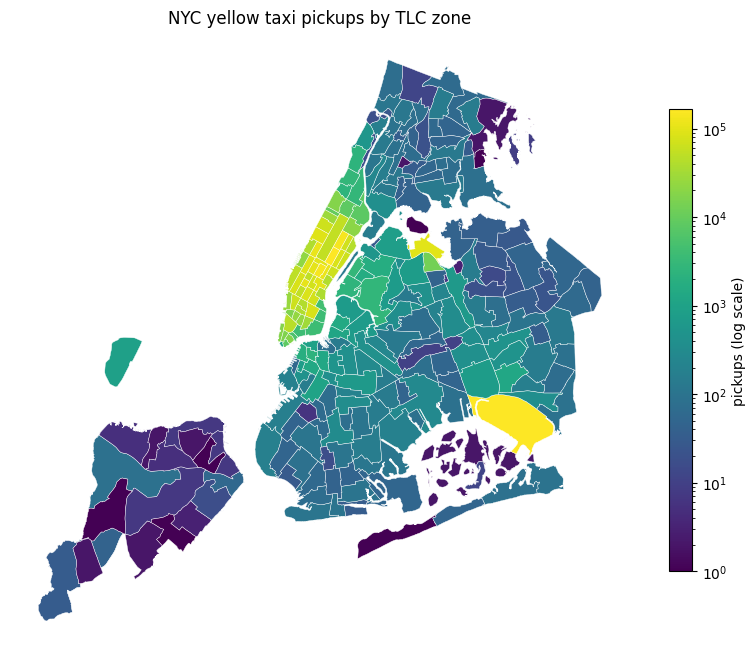

,LocationID,zone,borough,trips,avg_fare
131,132,JFK Airport,Queens,164957.0,45.72
236,237,Upper East Side South,Manhattan,163888.0,10.07
235,236,Upper East Side North,Manhattan,142776.0,10.69
160,161,Midtown Center,Manhattan,140025.0,12.45
141,142,Lincoln Square East,Manhattan,112137.0,11.31
161,162,Midtown East,Manhattan,109137.0,12.23
185,186,Penn Station/Madison Sq West,Manhattan,104008.0,12.98
229,230,Times Sq/Theatre District,Manhattan,101217.0,14.64
137,138,LaGuardia Airport,Queens,95320.0,31.55
169,170,Murray Hill,Manhattan,95213.0,12.42


In [8]:
import geopandas as gpd
from matplotlib.colors import LogNorm

pickup_counts = con.sql("""
    SELECT PULocationID AS LocationID,
           COUNT(*)     AS trips,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM sample_data.nyc.taxi
    GROUP BY PULocationID
""").df()

zones = gpd.read_file('data/taxi_zones/taxi_zones/taxi_zones.shp').to_crs(epsg=4326)
zones = zones.merge(pickup_counts, on='LocationID', how='left')
zones['trips'] = zones['trips'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
zones.plot(
    column='trips',
    cmap='viridis',
    norm=LogNorm(vmin=max(zones['trips'].min(), 1), vmax=zones['trips'].max()),
    linewidth=0.3,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'pickups (log scale)', 'shrink': 0.6},
    ax=ax,
)
ax.set_title('NYC yellow taxi pickups by TLC zone')
ax.set_axis_off()
plt.show()

zones[['LocationID', 'zone', 'borough', 'trips', 'avg_fare']] \
    .sort_values('trips', ascending=False).head(10)

## 6. Excel export — 2022 weekly trips + top-20 PU × DO pivot

Writes `output/taxi_2022_pivot.xlsx` with five sheets:
`weekly_trips_2022`, `pair_data_long`, `pivot_trip_count`, `pivot_avg_fare`,
`pivot_total_revenue`. Totals are Excel formulas (per the `xlsx` skill).

In [9]:
from pathlib import Path
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

out_path = Path('output/taxi_2022_pivot.xlsx')
out_path.parent.mkdir(exist_ok=True)

YEAR_FILTER = "tpep_pickup_datetime >= '2022-01-01' AND tpep_pickup_datetime < '2023-01-01'"

weekly = con.sql(f"""
    SELECT date_trunc('week', tpep_pickup_datetime) AS week_start,
           COUNT(*)                       AS trips,
           ROUND(AVG(fare_amount), 2)     AS avg_fare,
           ROUND(SUM(total_amount), 2)    AS total_revenue
    FROM sample_data.nyc.taxi
    WHERE {YEAR_FILTER}
      AND fare_amount > 0 AND trip_distance > 0
    GROUP BY 1 ORDER BY 1
""").df()

top_pu = con.sql(f"""
    SELECT PULocationID AS LocationID FROM sample_data.nyc.taxi
    WHERE {YEAR_FILTER} GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 20
""").df()['LocationID'].tolist()
top_do = con.sql(f"""
    SELECT DOLocationID AS LocationID FROM sample_data.nyc.taxi
    WHERE {YEAR_FILTER} GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 20
""").df()['LocationID'].tolist()

pairs = con.sql(f"""
    SELECT PULocationID, DOLocationID,
           COUNT(*)                    AS trips,
           ROUND(AVG(fare_amount), 2)  AS avg_fare,
           ROUND(SUM(total_amount), 2) AS total_revenue
    FROM sample_data.nyc.taxi
    WHERE {YEAR_FILTER}
      AND PULocationID IN ({','.join(map(str, top_pu))})
      AND DOLocationID IN ({','.join(map(str, top_do))})
    GROUP BY 1, 2
""").df()

zlu = gpd.read_file('data/taxi_zones/taxi_zones/taxi_zones.shp')[['LocationID', 'zone', 'borough']]
pairs = (pairs
    .merge(zlu.rename(columns={'LocationID': 'PULocationID', 'zone': 'PU_zone', 'borough': 'PU_borough'}), on='PULocationID')
    .merge(zlu.rename(columns={'LocationID': 'DOLocationID', 'zone': 'DO_zone', 'borough': 'DO_borough'}), on='DOLocationID'))

pu_order = (pairs.groupby('PU_zone')['trips'].sum().sort_values(ascending=False).index.tolist())
do_order = (pairs.groupby('DO_zone')['trips'].sum().sort_values(ascending=False).index.tolist())
piv_trips   = pairs.pivot(index='PU_zone', columns='DO_zone', values='trips').reindex(index=pu_order, columns=do_order)
piv_fare    = pairs.pivot(index='PU_zone', columns='DO_zone', values='avg_fare').reindex(index=pu_order, columns=do_order)
piv_revenue = pairs.pivot(index='PU_zone', columns='DO_zone', values='total_revenue').reindex(index=pu_order, columns=do_order)

ARIAL = Font(name='Arial')
ARIAL_BOLD = Font(name='Arial', bold=True)
ZERO_DASH_INT = '$#,##0;($#,##0);-'
ZERO_DASH_2DP = '$#,##0.00;($#,##0.00);-'
INT_FMT = '#,##0;(#,##0);-'

def apply_font(ws):
    for row in ws.iter_rows():
        for c in row:
            if c.font is None or c.font.name != 'Arial':
                c.font = ARIAL_BOLD if c.font and c.font.bold else ARIAL

def autosize(ws):
    for col in ws.columns:
        letter = get_column_letter(col[0].column)
        width = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[letter].width = min(max(width + 2, 10), 32)

wb = Workbook()

# Sheet 1: weekly_trips_2022
ws = wb.active
ws.title = 'weekly_trips_2022'
headers = ['week_start', 'trips', 'avg_fare', 'total_revenue']
ws.append(headers)
for h in ws[1]:
    h.font = ARIAL_BOLD
for _, r in weekly.iterrows():
    ws.append([r['week_start'].date(), int(r['trips']), float(r['avg_fare']), float(r['total_revenue'])])
n = len(weekly)
total_row = n + 2
ws.cell(row=total_row, column=1, value='Total / Avg').font = ARIAL_BOLD
ws.cell(row=total_row, column=2, value=f'=SUM(B2:B{n + 1})').font = ARIAL_BOLD
ws.cell(row=total_row, column=3, value=f'=AVERAGE(C2:C{n + 1})').font = ARIAL_BOLD
ws.cell(row=total_row, column=4, value=f'=SUM(D2:D{n + 1})').font = ARIAL_BOLD
for r in range(2, total_row + 1):
    ws.cell(row=r, column=2).number_format = INT_FMT
    ws.cell(row=r, column=3).number_format = ZERO_DASH_2DP
    ws.cell(row=r, column=4).number_format = ZERO_DASH_INT
ws.freeze_panes = 'A2'
apply_font(ws)
autosize(ws)

# Sheet 2: pair_data_long
ws = wb.create_sheet('pair_data_long')
cols = ['PU_zone', 'PU_borough', 'DO_zone', 'DO_borough', 'trips', 'avg_fare', 'total_revenue']
ws.append(cols)
for h in ws[1]:
    h.font = ARIAL_BOLD
sorted_pairs = pairs.sort_values('trips', ascending=False)[cols]
for _, r in sorted_pairs.iterrows():
    ws.append([r['PU_zone'], r['PU_borough'], r['DO_zone'], r['DO_borough'],
               int(r['trips']), float(r['avg_fare']), float(r['total_revenue'])])
last = len(sorted_pairs) + 1
for row in ws.iter_rows(min_row=2, max_row=last, min_col=5, max_col=5):
    row[0].number_format = INT_FMT
for row in ws.iter_rows(min_row=2, max_row=last, min_col=6, max_col=6):
    row[0].number_format = ZERO_DASH_2DP
for row in ws.iter_rows(min_row=2, max_row=last, min_col=7, max_col=7):
    row[0].number_format = ZERO_DASH_INT
ws.freeze_panes = 'A2'
apply_font(ws)
autosize(ws)

def write_matrix(ws, df, value_fmt, totals_formula='SUM'):
    nrows, ncols = df.shape
    ws.cell(row=1, column=1, value='PU_zone \\ DO_zone').font = ARIAL_BOLD
    for j, col in enumerate(df.columns, start=2):
        ws.cell(row=1, column=j, value=col).font = ARIAL_BOLD
    ws.cell(row=1, column=ncols + 2, value='Row total').font = ARIAL_BOLD
    for i, idx in enumerate(df.index, start=2):
        ws.cell(row=i, column=1, value=idx).font = ARIAL_BOLD
        for j, col in enumerate(df.columns, start=2):
            v = df.iat[i - 2, j - 2]
            if pd.isna(v):
                ws.cell(row=i, column=j, value=None)
            else:
                cell = ws.cell(row=i, column=j, value=float(v) if value_fmt != INT_FMT else int(v))
                cell.number_format = value_fmt
        first_col = get_column_letter(2)
        last_col = get_column_letter(ncols + 1)
        ws.cell(row=i, column=ncols + 2,
                value=f'={totals_formula}({first_col}{i}:{last_col}{i})').number_format = value_fmt
    totals_row = nrows + 2
    ws.cell(row=totals_row, column=1, value='Col total').font = ARIAL_BOLD
    for j in range(2, ncols + 2):
        letter = get_column_letter(j)
        ws.cell(row=totals_row, column=j,
                value=f'={totals_formula}({letter}2:{letter}{nrows + 1})').number_format = value_fmt
    letter_total = get_column_letter(ncols + 2)
    ws.cell(row=totals_row, column=ncols + 2,
            value=f'={totals_formula}({letter_total}2:{letter_total}{nrows + 1})').number_format = value_fmt
    ws.freeze_panes = 'B2'

ws = wb.create_sheet('pivot_trip_count');   write_matrix(ws, piv_trips,   INT_FMT,        'SUM'); apply_font(ws); autosize(ws)
ws = wb.create_sheet('pivot_avg_fare');     write_matrix(ws, piv_fare,    ZERO_DASH_2DP,  'AVERAGE'); apply_font(ws); autosize(ws)
ws = wb.create_sheet('pivot_total_revenue');write_matrix(ws, piv_revenue, ZERO_DASH_INT,  'SUM'); apply_font(ws); autosize(ws)

wb.save(out_path)
print(f'wrote {out_path} ({out_path.stat().st_size:,} bytes)')

wrote output/taxi_2022_pivot.xlsx (35,747 bytes)


## 7. Billboard pitch — data prep + PowerPoint export

Ranks NYC pickup zones by **average passenger spend** across yellow taxi
(`sample_data.nyc.taxi`) and rideshare (`sample_data.nyc.rideshare`) for
November 2022, filtered to zones with ≥1,000 trips. Emits `output/pitch_data.json`
and `output/overlap_map.png`, consumed by `build_billboard_pitch.mjs` to render
`output/billboard_pitch.pptx`.

/var/folders/bs/rpvjq3xx67d5n0qzrv_8g6nh0000gq/T/ipykernel_60676/3732959913.py:94: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', frameon=False, labelcolor='white', fontsize=10)
/var/folders/bs/rpvjq3xx67d5n0qzrv_8g6nh0000gq/T/ipykernel_60676/3732959913.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', frameon=False, labelcolor='white', fontsize=10)


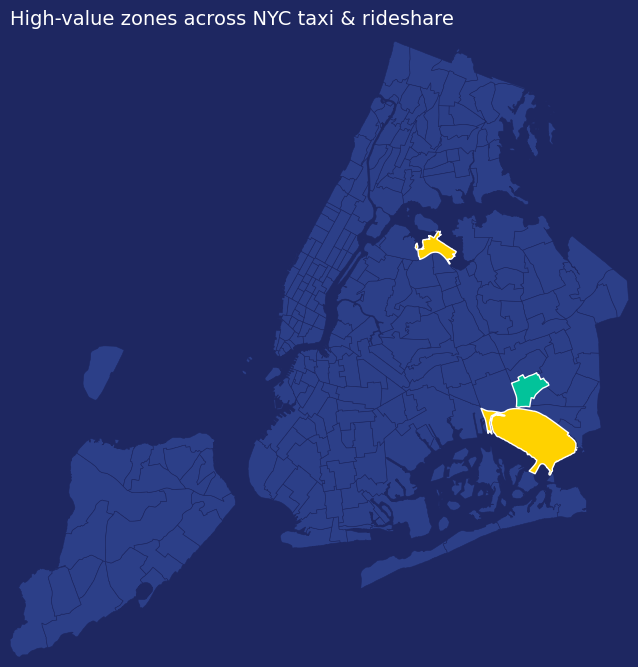

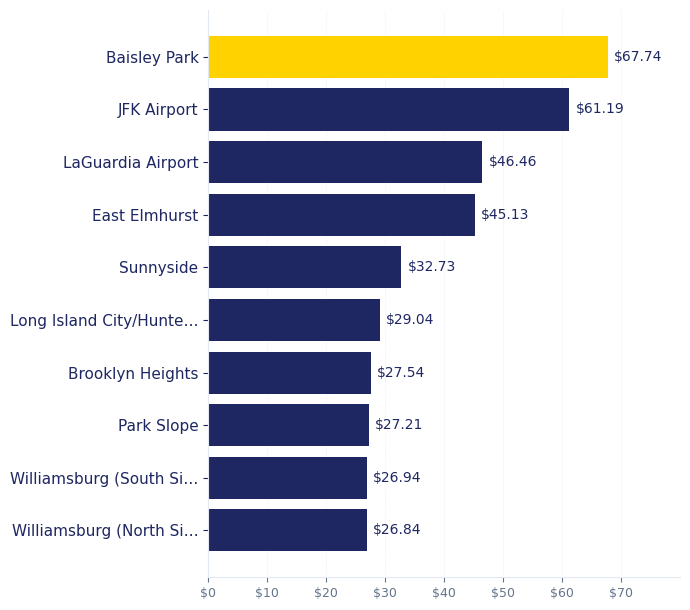

taxi top: Baisley Park $ 67.74
rideshare top: JFK Airport $ 74.95
overlap zones: ['JFK Airport', 'LaGuardia Airport']
top 3 picks: [('JFK Airport', 68.07, 'both'), ('Baisley Park', 64.35, 'taxi-only'), ('LaGuardia Airport', 54.23, 'both')]


In [10]:
import json
from pathlib import Path

NOV22_TAXI = "tpep_pickup_datetime >= '2022-11-01' AND tpep_pickup_datetime < '2022-12-01'"
NOV22_RS   = "pickup_datetime >= '2022-11-01' AND pickup_datetime < '2022-12-01'"

taxi_zone_stats = con.sql(f"""
    SELECT PULocationID AS LocationID,
           COUNT(*) AS trips,
           ROUND(AVG(total_amount), 2) AS avg_total
    FROM sample_data.nyc.taxi
    WHERE {NOV22_TAXI} AND total_amount > 0
    GROUP BY 1 HAVING COUNT(*) >= 1000
""").df()

rs_zone_stats = con.sql(f"""
    SELECT PULocationID AS LocationID,
           COUNT(*) AS trips,
           ROUND(AVG(base_passenger_fare + tolls + bcf + sales_tax
                     + congestion_surcharge + airport_fee + tips), 2) AS avg_total
    FROM sample_data.nyc.rideshare
    WHERE {NOV22_RS} AND base_passenger_fare > 0
    GROUP BY 1 HAVING COUNT(*) >= 1000
""").df()

zlu_df = gpd.read_file('data/taxi_zones/taxi_zones/taxi_zones.shp')[['LocationID', 'zone', 'borough']]
taxi_top = (taxi_zone_stats.merge(zlu_df, on='LocationID')
            .sort_values('avg_total', ascending=False).head(10).reset_index(drop=True))
rs_top   = (rs_zone_stats.merge(zlu_df, on='LocationID')
            .sort_values('avg_total', ascending=False).head(10).reset_index(drop=True))

overlap_ids = set(taxi_top['LocationID']) & set(rs_top['LocationID'])

union_ids = set(taxi_top['LocationID']) | set(rs_top['LocationID'])
taxi_map = taxi_top.set_index('LocationID')['avg_total'].to_dict()
rs_map   = rs_top.set_index('LocationID')['avg_total'].to_dict()
zone_map = zlu_df.set_index('LocationID')[['zone','borough']].to_dict('index')

pool = []
for lid in union_ids:
    t, r = taxi_map.get(lid), rs_map.get(lid)
    if t is not None and r is not None:
        score = (t + r) / 2; tag = 'both'
    elif t is not None:
        score = t * 0.95; tag = 'taxi-only'
    else:
        score = r * 0.95; tag = 'rideshare-only'
    pool.append({
        'LocationID': lid,
        'zone': zone_map[lid]['zone'],
        'borough': zone_map[lid]['borough'],
        'taxi_avg': t, 'rs_avg': r,
        'blended': round(score, 2), 'tag': tag,
    })
picks = sorted(pool, key=lambda x: x['blended'], reverse=True)[:3]

rationales = {
    138: 'LaGuardia: high-value business travelers, captive dwell at curbside taxi line.',
    132: 'JFK Airport: premium international + business arrivals, longest dwell of any zone.',
    1:   'Newark Airport: cross-state premium fares, dense out-of-town impressions.',
    230: 'Times Square: tourist + corporate mix, premium evening cabs ordered for shows.',
    161: 'Midtown Center: peak fare density during business hours, decision-maker volume.',
    162: 'Midtown East: corporate-HQ corridor, premium rides to/from offices.',
    163: 'Midtown North: dense fare zone with finance/media demographic.',
    170: 'Murray Hill: high-spend young-professional pickup density.',
    234: 'Union Square: mixed business/leisure with premium evening fares.',
    20:  'Baisley Park (Queens): long airport-adjacent fares — premium rider corridor near JFK.',
}
for p in picks:
    p['rationale'] = rationales.get(p['LocationID'],
        f"Top-10 on {p['tag']} with avg fare ${p['blended']:.0f} — premium rider mix in {p['borough']}.")

# Overlap map for slide 4
zones_geo = gpd.read_file('data/taxi_zones/taxi_zones/taxi_zones.shp').to_crs(epsg=4326)
pick_ids = {p['LocationID'] for p in picks}
zones_geo['is_overlap'] = zones_geo['LocationID'].isin(overlap_ids)
zones_geo['is_pick']    = zones_geo['LocationID'].isin(pick_ids)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='#1E2761')
ax.set_facecolor('#1E2761')
zones_geo.plot(ax=ax, color='#2C3F88', edgecolor='#1E2761', linewidth=0.4)
if zones_geo['is_overlap'].any():
    zones_geo[zones_geo['is_overlap']].plot(
        ax=ax, color='#FFD200', edgecolor='white', linewidth=1.0, label='Top-10 in both services')
non_overlap_picks = zones_geo[zones_geo['is_pick'] & ~zones_geo['is_overlap']]
if not non_overlap_picks.empty:
    non_overlap_picks.plot(ax=ax, color='#02C39A', edgecolor='white', linewidth=1.0,
                           label='Top-3 pick (single service)')
minx, miny, maxx, maxy = zones_geo.total_bounds
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_axis_off()
ax.set_title('High-value zones across NYC taxi & rideshare',
             color='white', fontsize=14, pad=12, loc='left')
ax.legend(loc='lower left', frameon=False, labelcolor='white', fontsize=10)
out_dir = Path('output'); out_dir.mkdir(exist_ok=True)
fig.savefig(out_dir / 'overlap_map.png', dpi=160, bbox_inches='tight',
            facecolor='#1E2761', edgecolor='none')
plt.show()

# Taxi top-10 bar chart PNG (more portable than embedded pptxgenjs chart)
fig2, ax2 = plt.subplots(figsize=(7, 6.2), facecolor='white')
ax2.set_facecolor('white')
labels = [r if len(r) <= 24 else r[:22] + '…' for r in taxi_top['zone'][::-1]]
values = taxi_top['avg_total'][::-1].tolist()
colors = ['#FFD200' if i == len(values) - 1 else '#1E2761' for i in range(len(values))]
bars = ax2.barh(labels, values, color=colors, edgecolor='none')
for bar, v in zip(bars, values):
    ax2.text(v + max(values) * 0.015, bar.get_y() + bar.get_height() / 2,
             f'${v:,.2f}', va='center', ha='left',
             fontsize=10, color='#1E2761')
ax2.set_xlim(0, max(values) * 1.18)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#E2E8F0')
ax2.spines['left'].set_color('#E2E8F0')
ax2.tick_params(axis='y', colors='#1E2761', labelsize=11)
ax2.tick_params(axis='x', colors='#64748B', labelsize=9)
ax2.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'${int(x)}'))
ax2.grid(axis='x', color='#E2E8F0', linewidth=0.5, linestyle=':')
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig(out_dir / 'taxi_top_bar.png', dpi=160, bbox_inches='tight',
             facecolor='white', edgecolor='none')
plt.show()

overlap_zone_rows = sorted(
    [{'LocationID': lid, 'zone': zone_map[lid]['zone'], 'borough': zone_map[lid]['borough'],
      'taxi_avg': taxi_map[lid], 'rs_avg': rs_map[lid],
      'blended': round((taxi_map[lid] + rs_map[lid]) / 2, 2)} for lid in overlap_ids],
    key=lambda x: x['blended'], reverse=True)

payload = {
    'window': 'November 2022',
    'volume_filter': 'pickup zones with ≥1,000 trips',
    'taxi_total_trips': int(taxi_zone_stats['trips'].sum()),
    'rs_total_trips':   int(rs_zone_stats['trips'].sum()),
    'eligible_zones_taxi': int(len(taxi_zone_stats)),
    'eligible_zones_rs':   int(len(rs_zone_stats)),
    'overlap_count': len(overlap_ids),
    'taxi_top':     taxi_top[['zone','borough','trips','avg_total']].to_dict('records'),
    'rideshare_top': rs_top[['zone','borough','trips','avg_total']].to_dict('records'),
    'overlap_zones': overlap_zone_rows,
    'top_3_picks': picks,
}
(out_dir / 'pitch_data.json').write_text(json.dumps(payload, indent=2, default=str))
print('taxi top:', taxi_top.iloc[0]['zone'], '$', taxi_top.iloc[0]['avg_total'])
print('rideshare top:', rs_top.iloc[0]['zone'], '$', rs_top.iloc[0]['avg_total'])
print('overlap zones:', [r['zone'] for r in overlap_zone_rows])
print('top 3 picks:', [(p['zone'], p['blended'], p['tag']) for p in picks])